In [1]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


# Import Required Library

In [2]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

# Data Processing

## Read the Environment Dataset

In [3]:
root = "./DataCollect/"

def read_data(path, filename):
    return pd.read_excel(os.path.join(path, filename), index_col=None)

df_env = read_data(root, 'Env_Sensing_Data.xlsx')
df_env.columns = df_env.columns.str.strip()
df_env.head()

,timestamp,temperature,humidity,lightPercent,pirState,pirDetected
0,2026-02-21 04:11:37,20.1,42,47.57,0,0
1,2026-02-21 04:12:37,20.4,43,47.57,0,0
2,2026-02-21 04:13:37,20.7,44,48.16,0,0
3,2026-02-21 04:14:37,20.9,44,46.86,0,0
4,2026-02-21 04:15:37,21.2,45,49.08,0,0


## Read the Battery Dataset

In [4]:
df_battery = read_data(root, 'Battery_cons_combine.xlsx')
df_battery.columns = df_battery.columns.str.strip()
df_battery.head()

,timestamp_charge,Charge,Charge Rate (mW)
0,2026-02-21 04:11:43,1.00,0
1,2026-02-21 04:12:43,1.00,-35744
2,2026-02-21 04:13:43,1.00,-35792
3,2026-02-21 04:14:43,1.00,-35952
4,2026-02-21 04:15:43,0.99,-37343


## Data Alignment

In [5]:
pd.set_option('display.width', None)        
pd.set_option('display.max_columns', None)  
pd.set_option('display.expand_frame_repr', False)  

In [6]:
def merge_data(df_env, df_battery):
    # Convert timestamp
    df_env['timestamp'] = pd.to_datetime(df_env['timestamp'])
    df_battery['timestamp_charge'] = pd.to_datetime(df_battery['timestamp_charge'])
    
    # Create minute-level alignment keys (truncate to minute-level precision)
    df_env['time_minute'] = df_env['timestamp'].dt.floor('min')
    df_battery['time_minute'] = df_battery['timestamp_charge'].dt.floor('min')
    
    # Convert battery charge from 0-1 to 0-100%
    df_battery['Charge_percent'] = df_battery['Charge'] * 100

    # ===== Calculate charge_rate (%/min) on battery data before merging =====
    df_battery = df_battery.sort_values('time_minute').reset_index(drop=True)
    df_battery['time_diff_min'] = (
        df_battery['time_minute'].diff().dt.total_seconds() / 60
    )
    df_battery['charge_diff'] = df_battery['Charge_percent'].diff()

    # Raw rate: %/min
    df_battery['charge_rate'] = (
        df_battery['charge_diff'] / df_battery['time_diff_min']
    )

    # First row has no previous value → set to 0
    df_battery.loc[0, 'charge_rate'] = 0

    # If the absolute difference from the previous value exceeds 10 → set to 0
    # (covers large gaps between sessions or sensor jumps)
    df_battery.loc[
        df_battery['charge_rate'].abs() > 10, 'charge_rate'
    ] = 0

    # Drop helper columns
    df_battery = df_battery.drop(columns=['time_diff_min', 'charge_diff'])
    # =========================================================================

    # Check data counts before merging
    print(f"Environment data records: {len(df_env)}")
    print(f"Battery data records: {len(df_battery)}")
    print(f"Unique minutes in environment data: {df_env['time_minute'].nunique()}")
    print(f"Unique minutes in battery data: {df_battery['time_minute'].nunique()}")
    
    # Merge the data (based on the criterion of equal minutes)
    df_merged = pd.merge(
        df_env,
        df_battery[['time_minute', 'Charge_percent', 'charge_rate',
                     'Charge Rate (mW)']],
        on='time_minute',
        how='inner'
    )
    
    # Select and reorder columns
    df_merged = df_merged[[
        'time_minute',
        'temperature',
        'humidity',
        'lightPercent',
        'pirDetected',
        'Charge_percent',
        'charge_rate',
        'Charge Rate (mW)'
    ]]
    
    # Rename columns
    df_merged = df_merged.rename(columns={
        'time_minute':      'timestamp',
        'Charge Rate (mW)': 'power_consumption_mW'
    })
    
    return df_merged

# ===== Execute =====
df_merged = merge_data(df_env, df_battery)
df_merged['timestamp'] = df_merged['timestamp'].dt.strftime('%Y-%m-%d %H:%M')
print(f"\nMerged {len(df_merged)} records")
print(f"Expected 3753 records, merged {len(df_merged)}, lost {3753 - len(df_merged)}")
print(df_merged.head(10))

# Check for missing minutes
missing_minutes = set(df_env['time_minute']) - set(df_battery['time_minute'])
if missing_minutes:
    print(f"\nWarning: {len(missing_minutes)} timestamps missing from battery data:")
    for minute in sorted(list(missing_minutes))[:10]:
        print(f"  {minute}")
    if len(missing_minutes) > 10:
        print(f"  ... and {len(missing_minutes) - 10} more")

Environment data records: 3753
Battery data records: 3753
Unique minutes in environment data: 3753
Unique minutes in battery data: 3753

Merged 3753 records
Expected 3753 records, merged 3753, lost 0
          timestamp  temperature  humidity  lightPercent  pirDetected  Charge_percent  charge_rate  power_consumption_mW
0  2026-02-21 04:11         20.1        42         47.57            0           100.0          0.0                     0
1  2026-02-21 04:12         20.4        43         47.57            0           100.0          0.0                -35744
2  2026-02-21 04:13         20.7        44         48.16            0           100.0          0.0                -35792
3  2026-02-21 04:14         20.9        44         46.86            0           100.0          0.0                -35952
4  2026-02-21 04:15         21.2        45         49.08            0            99.0         -1.0                -37343
5  2026-02-21 04:16         21.3        45         46.40            0     

## Visualization

During the data visualisation stage, variations in data collection density across different days were observed, with some days containing approximately 300 records while others had only around 150. Therefore, careful consideration was required in constructing the time axis to ensure both the accuracy and interpretability of the visualisation.

Two visualisation approaches were considered in this study. The first approach uses the original timestamp as the x-axis to directly plot the temporal evolution of each variable. This method preserves the true sampling distribution of the data, including irregular sampling intervals, data gaps, and discontinuities, thereby maintaining the inherent temporal structure of the dataset.

The second approach involves compressing the time axis through automatic date scaling, which visually distributes data points more evenly across the plot. However, this method partially obscures the actual time intervals between observations, making the data appear as if it were sampled at uniform intervals, and thus potentially masking the underlying irregularities in sampling density.

Building upon these approaches, it is further noted that data collection in this study only occurs during periods when the laptop is actively in use. As a result, there are significant time gaps between different usage sessions, which may span several hours or even multiple days. Directly connecting all data points in such cases would introduce misleading continuous trends across periods where no data was collected.

To address this issue, a gap-aware visualisation strategy was implemented. Specifically, when the time difference between consecutive data points exceeds a predefined threshold (e.g., one hour), the line is intentionally broken in the plot. This approach explicitly preserves the discontinuities in the data collection process, preventing erroneous connections across separate sessions while maintaining the integrity of the time axis. As a result, the visualisation more accurately reflects the true data acquisition process and improves the reliability of interpretation.

Taking these factors into account, two complementary strategies were adopted for raw data visualisation. On one hand, the original timestamp was used as the x-axis, combined with the gap-aware line-breaking mechanism, to faithfully represent the temporal structure and discontinuities in the data. On the other hand, an index-based representation was used as a supplementary visualisation method to examine trends with respect to sampling order, thereby avoiding visual sparsity caused by large time gaps. The combination of these approaches enables a more comprehensive understanding of the dataset from multiple perspectives.

In addition to time-series analysis, statistical distribution plots (histograms) were generated for each variable to examine their overall distributions and identify potential outliers. Together, these visualisation techniques provide an intuitive understanding of both temporal dynamics and statistical characteristics of the dataset.

### Original data

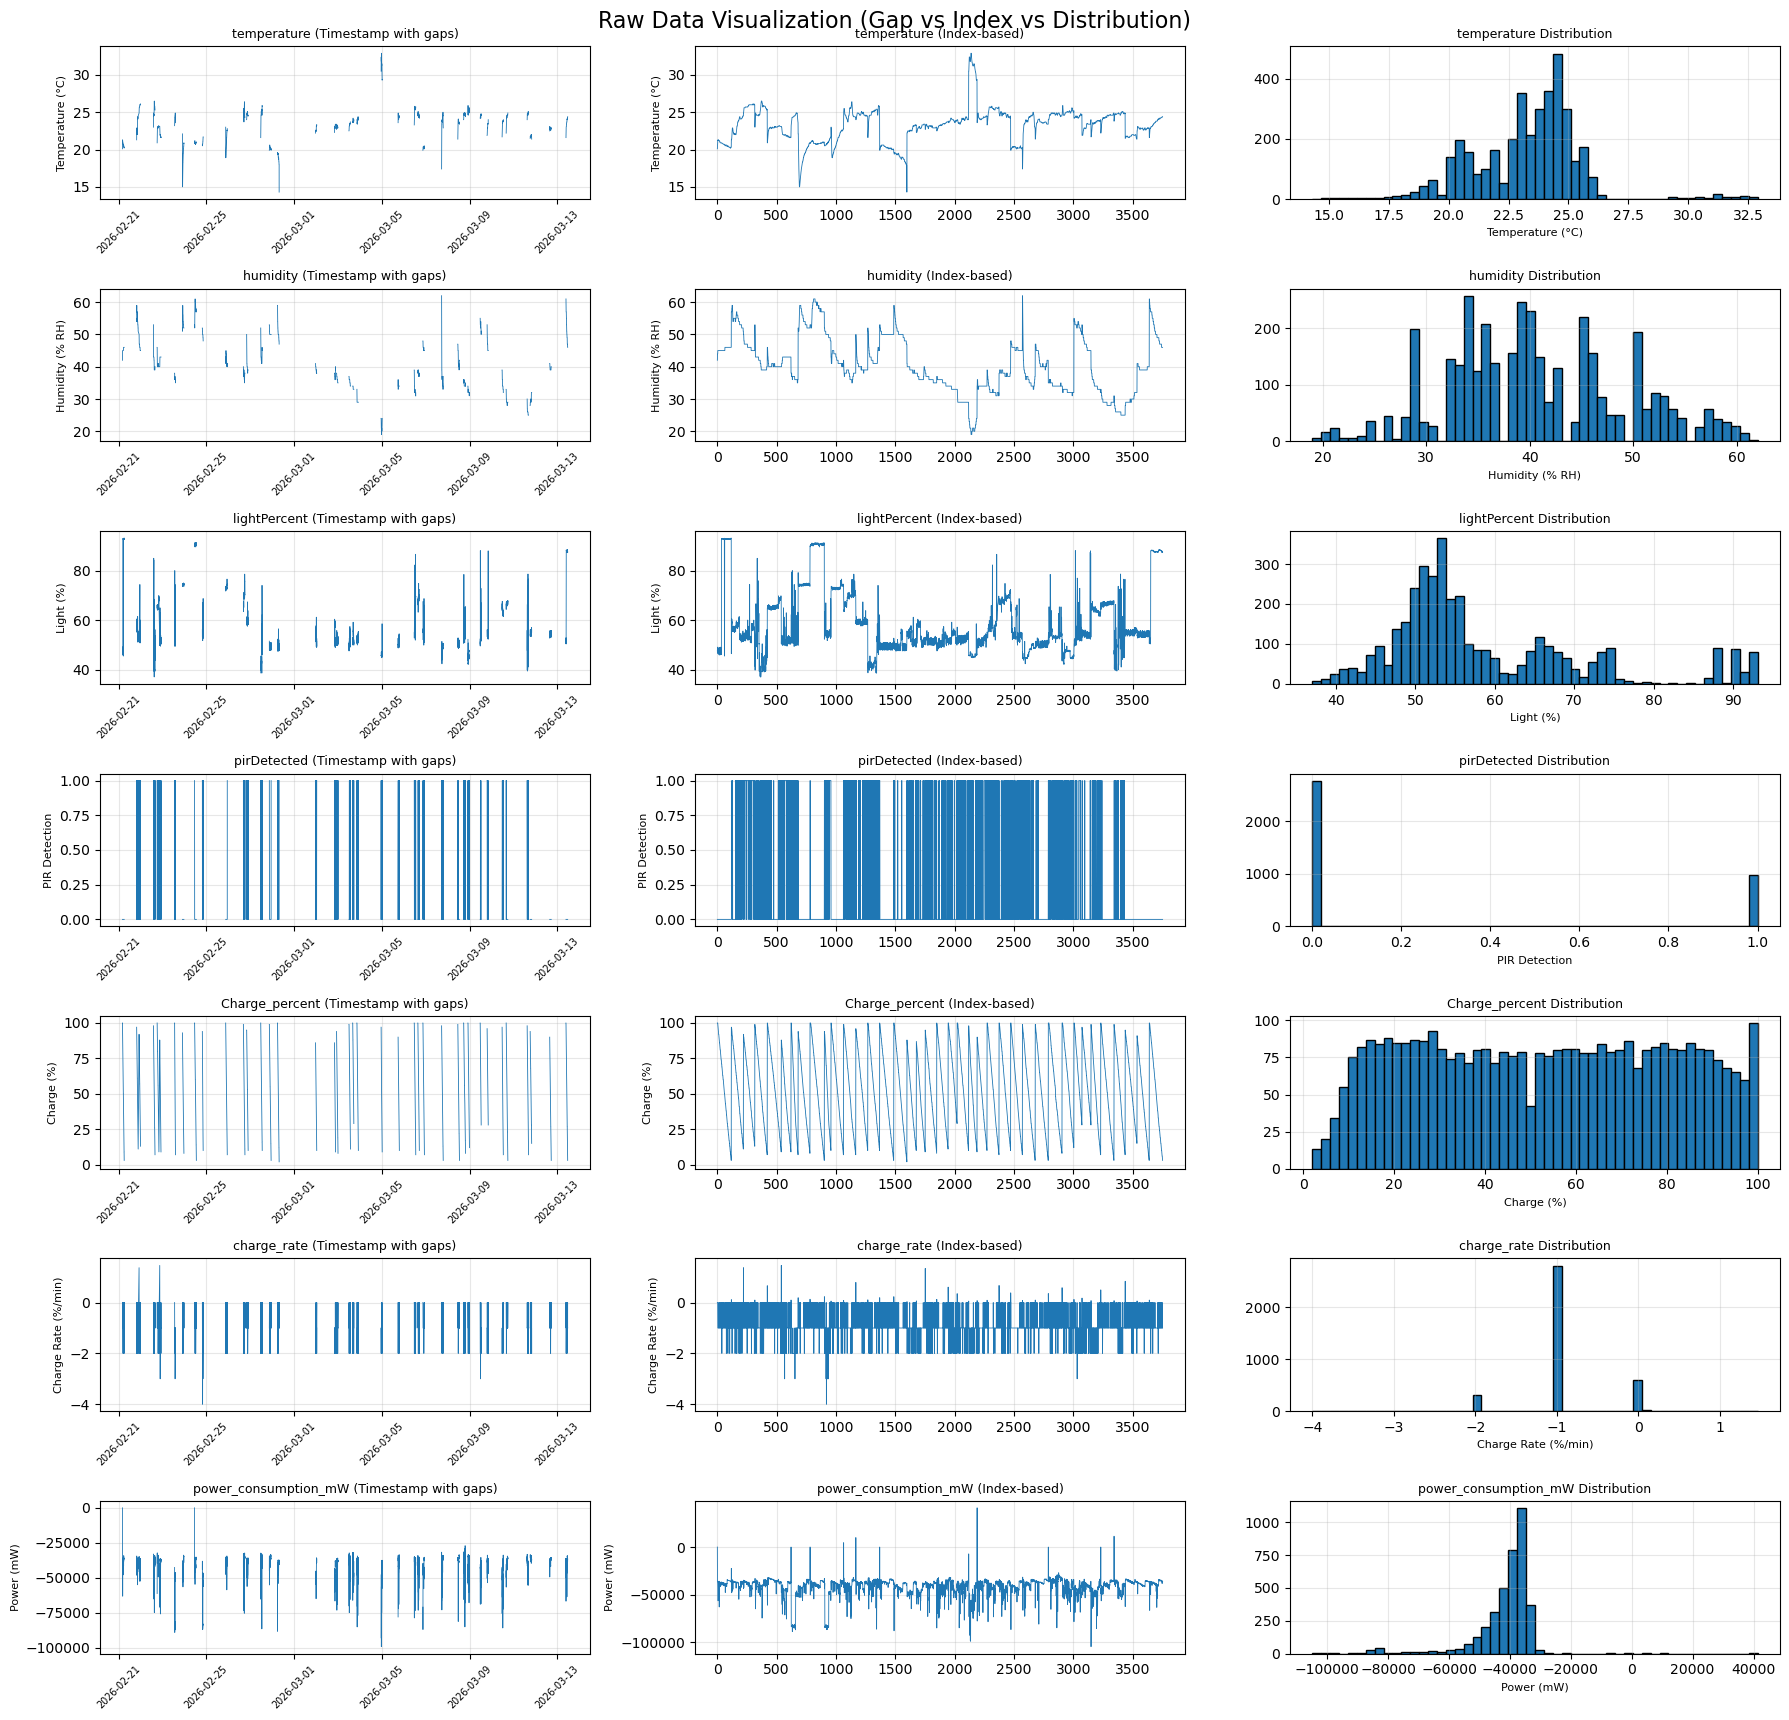


=== Raw Data Statistics ===
Total records: 3753
Time range: 2026-02-21 04:11:00 to 2026-03-13 11:14:00

Missing values:
temperature             0
humidity                0
lightPercent            0
pirDetected             0
Charge_percent          0
charge_rate             0
power_consumption_mW    0
dtype: int64

Basic stats:
  temperature: mean=23.25, std=2.20
  humidity: mean=40.53, std=8.56
  lightPercent: mean=58.59, std=12.52
  Charge_percent: mean=52.82, std=27.22
  charge_rate: mean=-0.91, std=0.51
  power_consumption_mW: mean=-41498.49, std=9815.88


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def visualize_with_gap_and_index(df, gap_minutes=60):
    """
    Visualization of raw data:
    Left: timestamp-based (with gaps)
    Middle: index-based (continuous)
    Right: distribution (histogram)
    """
    
    df_viz = df.copy()
    df_viz['timestamp'] = pd.to_datetime(df_viz['timestamp'])
    df_viz = df_viz.sort_values('timestamp').reset_index(drop=True)
    
    # Compute time difference (in minutes)
    time_diff = df_viz['timestamp'].diff().dt.total_seconds() / 60
    
    # Create gap version (break lines when gap is large)
    df_gap = df_viz.copy()
    for col in ['temperature', 'humidity', 'lightPercent',
                'pirDetected', 'Charge_percent', 'charge_rate',
                'power_consumption_mW']:
        if col in df_gap.columns:
            df_gap.loc[time_diff > gap_minutes, col] = np.nan

    variables = [
        ('temperature',          'Temperature (°C)'),
        ('humidity',             'Humidity (% RH)'),
        ('lightPercent',         'Light (%)'),
        ('pirDetected',          'PIR Detection'),
        ('Charge_percent',       'Charge (%)'),
        ('charge_rate',          'Charge Rate (%/min)'),
        ('power_consumption_mW', 'Power (mW)'),
    ]

    # Only keep variables that exist in the dataframe
    variables = [(col, ylabel) for col, ylabel in variables
                 if col in df_viz.columns]
    
    fig, axes = plt.subplots(len(variables), 3,
                             figsize=(18, 2.5 * len(variables)))
    fig.suptitle('Raw Data Visualization (Gap vs Index vs Distribution)',
                 fontsize=16)

    for i, (col, ylabel) in enumerate(variables):
        
        # Left: timestamp with gaps
        axes[i, 0].plot(df_gap['timestamp'], df_gap[col], linewidth=0.6)
        axes[i, 0].set_title(f'{col} (Timestamp with gaps)', fontsize=9)
        axes[i, 0].set_ylabel(ylabel, fontsize=8)
        axes[i, 0].tick_params(axis='x', rotation=45, labelsize=7)
        axes[i, 0].grid(True, alpha=0.3)
        
        # Middle: index-based
        axes[i, 1].plot(df_viz.index, df_viz[col], linewidth=0.6)
        axes[i, 1].set_title(f'{col} (Index-based)', fontsize=9)
        axes[i, 1].set_ylabel(ylabel, fontsize=8)
        axes[i, 1].grid(True, alpha=0.3)
        
        # Right: distribution
        axes[i, 2].hist(df_viz[col].dropna(), bins=50, edgecolor='black')
        axes[i, 2].set_title(f'{col} Distribution', fontsize=9)
        axes[i, 2].set_xlabel(ylabel, fontsize=8)
        axes[i, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ===== Statistics Output =====
    stat_cols = ['temperature', 'humidity', 'lightPercent',
                 'pirDetected', 'Charge_percent', 'charge_rate',
                 'power_consumption_mW']
    stat_cols = [c for c in stat_cols if c in df_viz.columns]

    print("\n=== Raw Data Statistics ===")
    print(f"Total records: {len(df_viz)}")
    print(f"Time range: {df_viz['timestamp'].min()} to {df_viz['timestamp'].max()}")

    print("\nMissing values:")
    print(df_viz[stat_cols].isnull().sum())

    print("\nBasic stats:")
    for col in stat_cols:
        if col == 'pirDetected':
            continue   # binary, skip mean/std
        mean_val = df_viz[col].mean()
        std_val  = df_viz[col].std()
        print(f"  {col}: mean={mean_val:.2f}, std={std_val:.2f}")

# ===== Run =====
visualize_with_gap_and_index(df_merged)

### The second method but not used after considering

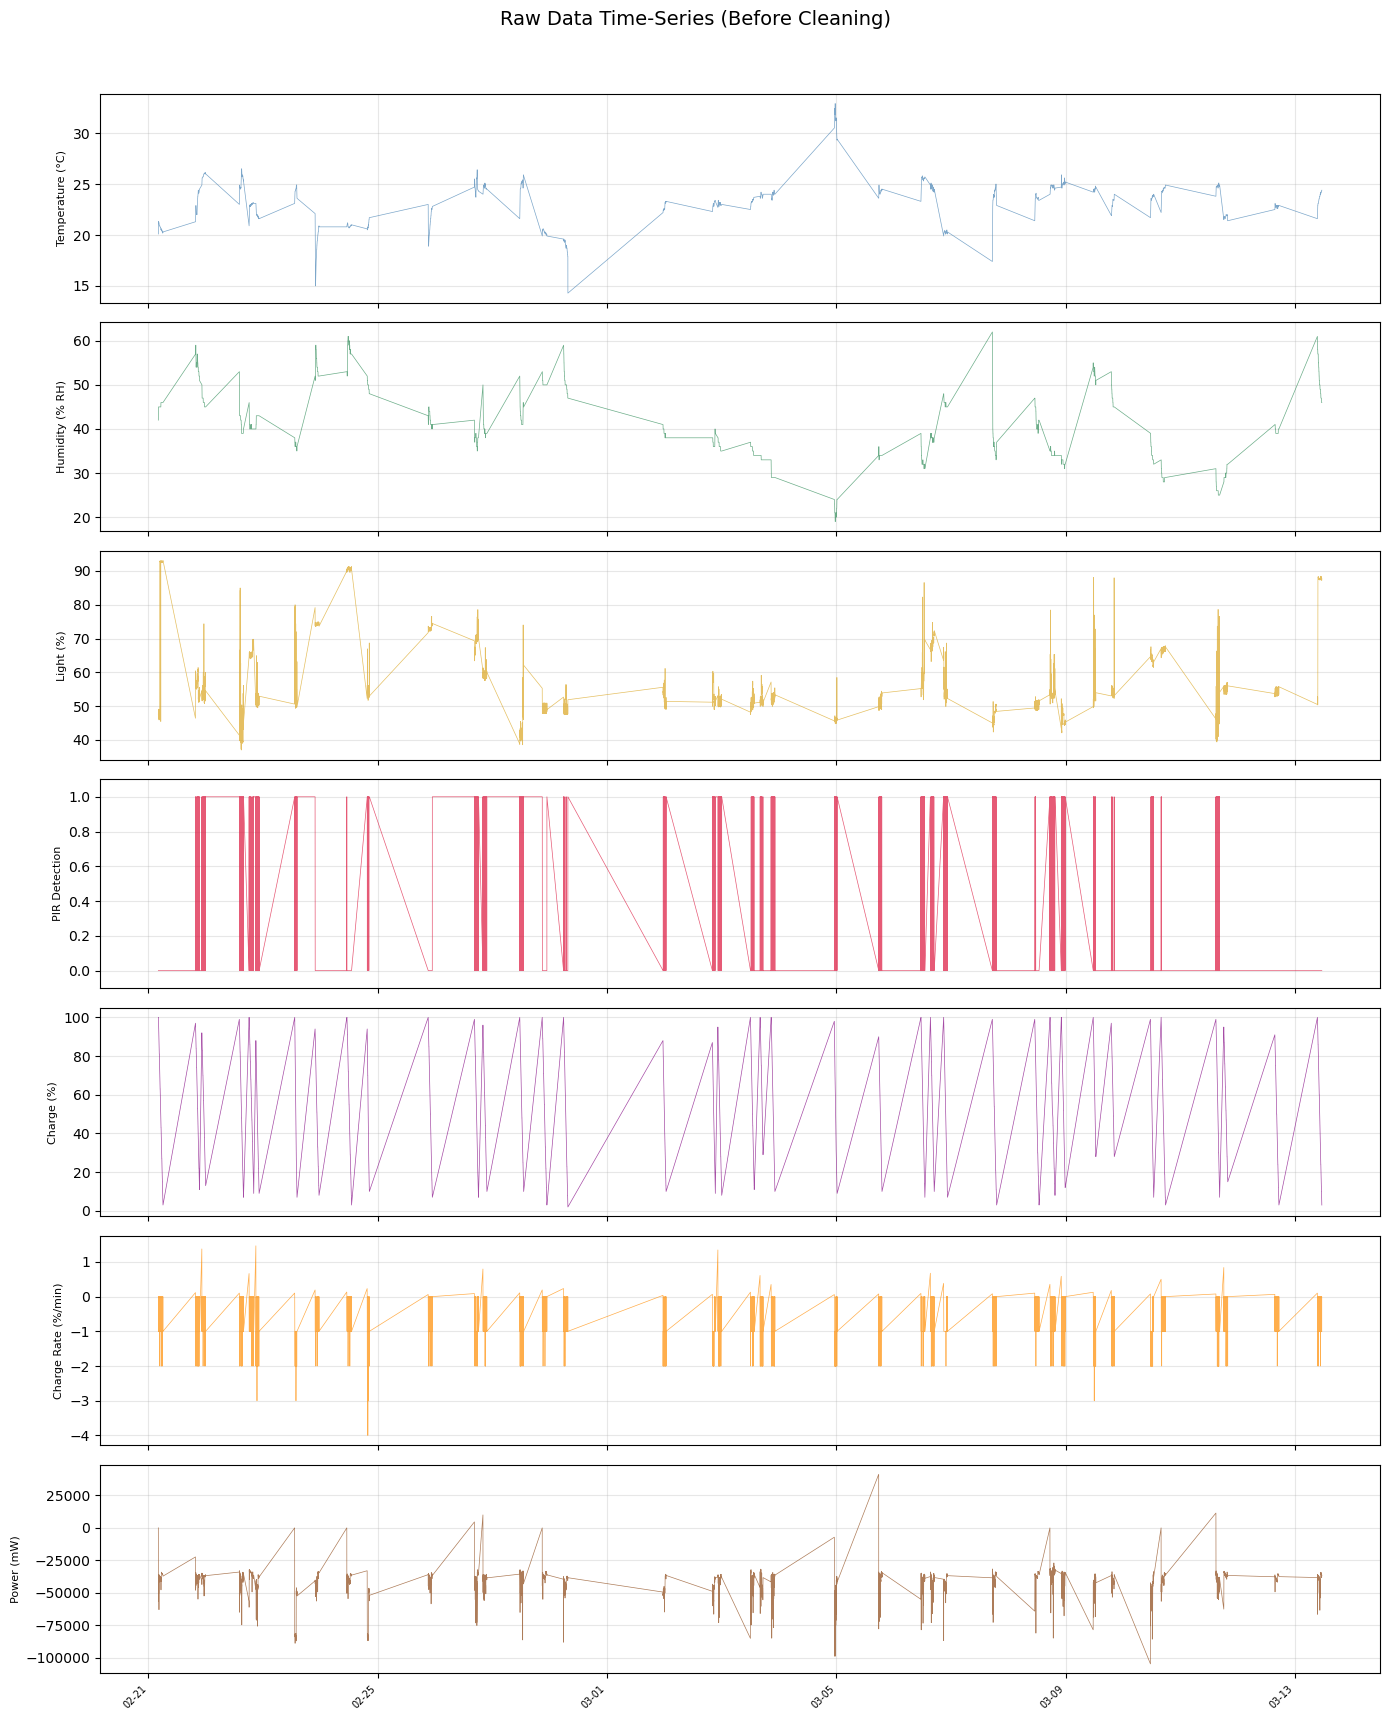

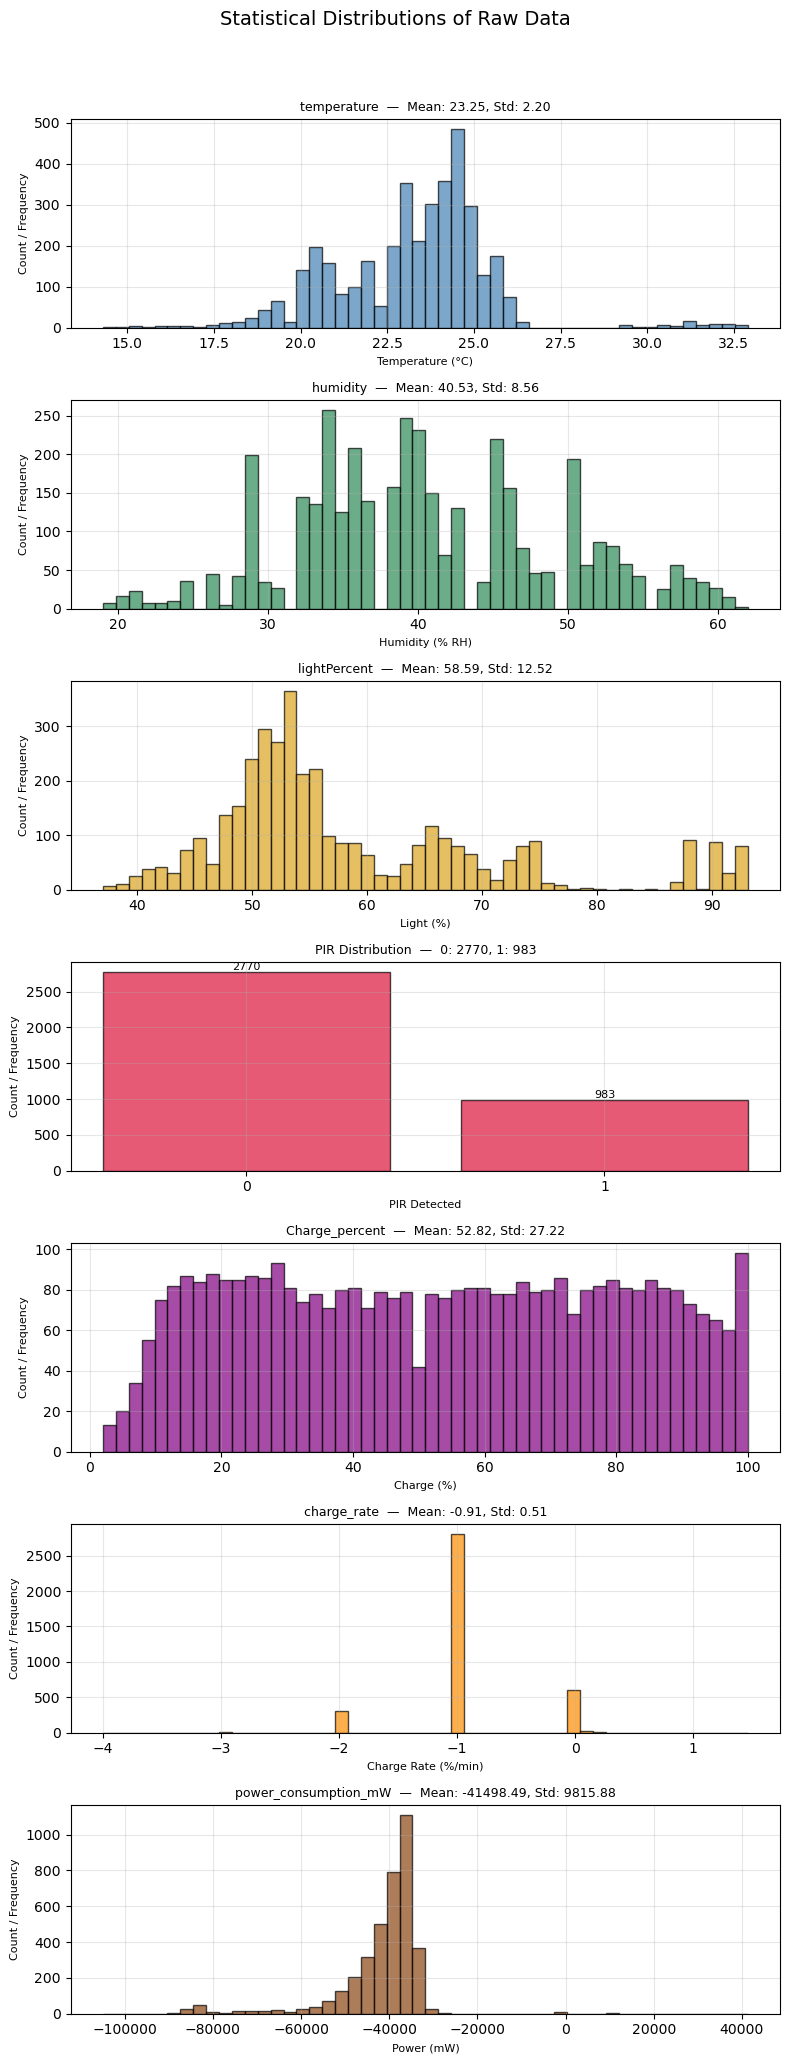


RAW DATA STATISTICS
Total records:  3753
Time range:     2026-02-21 04:11:00 to 2026-03-13 11:14:00
Time duration:  20 days 07:03:00

Missing values:
  temperature              : 0 (0.00%)
  humidity                 : 0 (0.00%)
  lightPercent             : 0 (0.00%)
  pirDetected              : 0 (0.00%)
  Charge_percent           : 0 (0.00%)
  charge_rate              : 0 (0.00%)
  power_consumption_mW     : 0 (0.00%)

Basic statistics:
  temperature:
    Min:    14.30
    Max:    32.90
    Mean:   23.25
    Std:    2.20
    Median: 23.60
  humidity:
    Min:    19.00
    Max:    62.00
    Mean:   40.53
    Std:    8.56
    Median: 40.00
  lightPercent:
    Min:    37.00
    Max:    93.11
    Mean:   58.59
    Std:    12.52
    Median: 54.04
  Charge_percent:
    Min:    2.00
    Max:    100.00
    Mean:   52.82
    Std:    27.22
    Median: 53.00
  charge_rate:
    Min:    -4.00
    Max:    1.46
    Mean:   -0.91
    Std:    0.51
    Median: -1.00
  power_consumption_mW:
    Min:   

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def visualize_raw_data(df):
    """
    Visualize distribution and time-series characteristics of raw data.
    """
    df_viz = df.copy()
    df_viz['timestamp'] = pd.to_datetime(df_viz['timestamp'])

    all_cols = ['temperature', 'humidity', 'lightPercent',
                'pirDetected', 'Charge_percent', 'charge_rate',
                'power_consumption_mW']
    plot_cols = [c for c in all_cols if c in df_viz.columns]
    n = len(plot_cols)

    colors = {
        'temperature':          'steelblue',
        'humidity':             'seagreen',
        'lightPercent':         'goldenrod',
        'pirDetected':          'crimson',
        'Charge_percent':       'purple',
        'charge_rate':          'darkorange',
        'power_consumption_mW': 'saddlebrown',
    }
    ylabels = {
        'temperature':          'Temperature (°C)',
        'humidity':             'Humidity (% RH)',
        'lightPercent':         'Light (%)',
        'pirDetected':          'PIR Detection',
        'Charge_percent':       'Charge (%)',
        'charge_rate':          'Charge Rate (%/min)',
        'power_consumption_mW': 'Power (mW)',
    }

    # ================================================================
    # Figure 1: Time-series plots
    # ================================================================
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n))
    fig.suptitle('Raw Data Time-Series (Before Cleaning)', fontsize=14)

    for i, col in enumerate(plot_cols):
        ax = axes[i]
        ax.plot(df_viz['timestamp'], df_viz[col],
                color=colors.get(col, 'gray'),
                alpha=0.7, linewidth=0.5)
        ax.set_ylabel(ylabels.get(col, col), fontsize=8)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=8))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        plt.setp(ax.xaxis.get_majorticklabels(),
                 rotation=45, ha='right', fontsize=7)
        ax.grid(True, alpha=0.3)
        if col == 'pirDetected':
            ax.set_ylim(-0.1, 1.1)
        if i < n - 1:
            ax.set_xticklabels([])  # Hide x labels on all but the last row

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # ================================================================
    # Figure 2: Distribution plots
    # ================================================================
    fig2, axes2 = plt.subplots(n, 1, figsize=(8, 3 * n))
    fig2.suptitle('Statistical Distributions of Raw Data', fontsize=14)

    for i, col in enumerate(plot_cols):
        ax = axes2[i]
        if col == 'pirDetected':
            counts = df_viz[col].value_counts().sort_index()
            bars = ax.bar(counts.index, counts.values,
                          color=colors.get(col, 'gray'),
                          edgecolor='black', alpha=0.7)
            ax.set_title(
                f'PIR Distribution  —  '
                f'0: {counts.get(0, 0)}, 1: {counts.get(1, 0)}',
                fontsize=9)
            ax.set_xlabel('PIR Detected', fontsize=8)
            ax.set_xticks([0, 1])
            for bar in bars:
                h = bar.get_height()
                ax.text(bar.get_x() + bar.get_width() / 2, h,
                        f'{int(h)}', ha='center', va='bottom', fontsize=8)
        else:
            mean_v = df_viz[col].mean()
            std_v  = df_viz[col].std()
            ax.hist(df_viz[col].dropna(), bins=50,
                    color=colors.get(col, 'gray'),
                    edgecolor='black', alpha=0.7)
            ax.set_title(
                f'{col}  —  Mean: {mean_v:.2f}, Std: {std_v:.2f}',
                fontsize=9)
            ax.set_xlabel(ylabels.get(col, col), fontsize=8)
        ax.set_ylabel('Count / Frequency', fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # ================================================================
    # Statistics output
    # ================================================================
    print("\n" + "=" * 50)
    print("RAW DATA STATISTICS")
    print("=" * 50)
    print(f"Total records:  {len(df_viz)}")
    print(f"Time range:     {df_viz['timestamp'].min()} "
          f"to {df_viz['timestamp'].max()}")
    print(f"Time duration:  "
          f"{df_viz['timestamp'].max() - df_viz['timestamp'].min()}")

    print("\nMissing values:")
    for col in plot_cols:
        n_missing = df_viz[col].isnull().sum()
        print(f"  {col:<25s}: {n_missing} "
              f"({n_missing / len(df_viz) * 100:.2f}%)")

    print("\nBasic statistics:")
    for col in plot_cols:
        if col == 'pirDetected':
            continue
        print(f"  {col}:")
        print(f"    Min:    {df_viz[col].min():.2f}")
        print(f"    Max:    {df_viz[col].max():.2f}")
        print(f"    Mean:   {df_viz[col].mean():.2f}")
        print(f"    Std:    {df_viz[col].std():.2f}")
        print(f"    Median: {df_viz[col].median():.2f}")

# ===== Execute =====
visualize_raw_data(df_merged)

### Data cleaning

A small number of missing values (n=1 per variable) remain after interpolation, primarily due to boundary conditions where linear interpolation cannot be applied.
Remaining missing values after interpolation are handled using forward and backward filling to ensure a complete dataset for subsequent analysis.

In [9]:
import pandas as pd
import numpy as np

def clean_data(df):
    df_clean = df.copy()

    # ===== 1. Timestamp Processing =====
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
    df_clean = df_clean.sort_values('timestamp').reset_index(drop=True)

    # ===== 2. Outlier Detection (Physical Constraints) =====
    # charge_rate is pre-computed in merge_data, used here for filtering only
    outlier_mask = (
        (df_clean['temperature'] < 0) | (df_clean['temperature'] > 45) |
        (df_clean['humidity'] < 10)   | (df_clean['humidity'] > 90)   |
        (df_clean['lightPercent'] < 0) | (df_clean['lightPercent'] > 100) |
        (df_clean['power_consumption_mW'] >= 0) |
        (df_clean['power_consumption_mW'] < -80000) |  # exceeds 80W
        (df_clean['charge_rate'] > 0) |                # charging detected
        (df_clean['charge_rate'].abs() > 5)            # >5%/min
    )

    outliers_removed = outlier_mask.sum()

    # Set outliers to NaN (preserve rows for interpolation)
    df_clean.loc[outlier_mask, [
        'temperature', 'humidity', 'lightPercent',
        'power_consumption_mW', 'charge_rate'
    ]] = np.nan

    # ===== 3. Linear Interpolation for Missing Values =====
    numeric_cols = ['temperature', 'humidity', 'lightPercent',
                    'power_consumption_mW', 'charge_rate']

    rows_with_missing_before = df_clean[numeric_cols].isnull().any(axis=1).sum()
    df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(method='linear')
    missing_rate = rows_with_missing_before / len(df_clean)

    # ===== 4. Handle boundary missing values =====
    df_clean = df_clean.bfill().ffill()

    # ===== 5. Smoothed version (5-point moving average, stored separately) =====
    df_smooth = df_clean.copy()
    df_smooth[numeric_cols] = df_smooth[numeric_cols].rolling(
        window=5, min_periods=1
    ).mean()

    # ===== 6. Cleaning Summary =====
    print("\n=== Data Cleaning Summary ===")
    print(f"Total records: {len(df_clean)}")
    print(f"Outliers removed (set as NaN): {outliers_removed}")
    print(f"Missing rate: {missing_rate*100:.2f}%")
    print("\nFinal missing values:")
    print(df_clean[numeric_cols].isnull().sum())

    return df_clean, df_smooth

# ===== Execute =====
df_cleaned, df_smoothed = clean_data(df_merged)


=== Data Cleaning Summary ===
Total records: 3753
Outliers removed (set as NaN): 122
Missing rate: 3.25%

Final missing values:
temperature             0
humidity                0
lightPercent            0
power_consumption_mW    0
charge_rate             0
dtype: int64


### Comparison

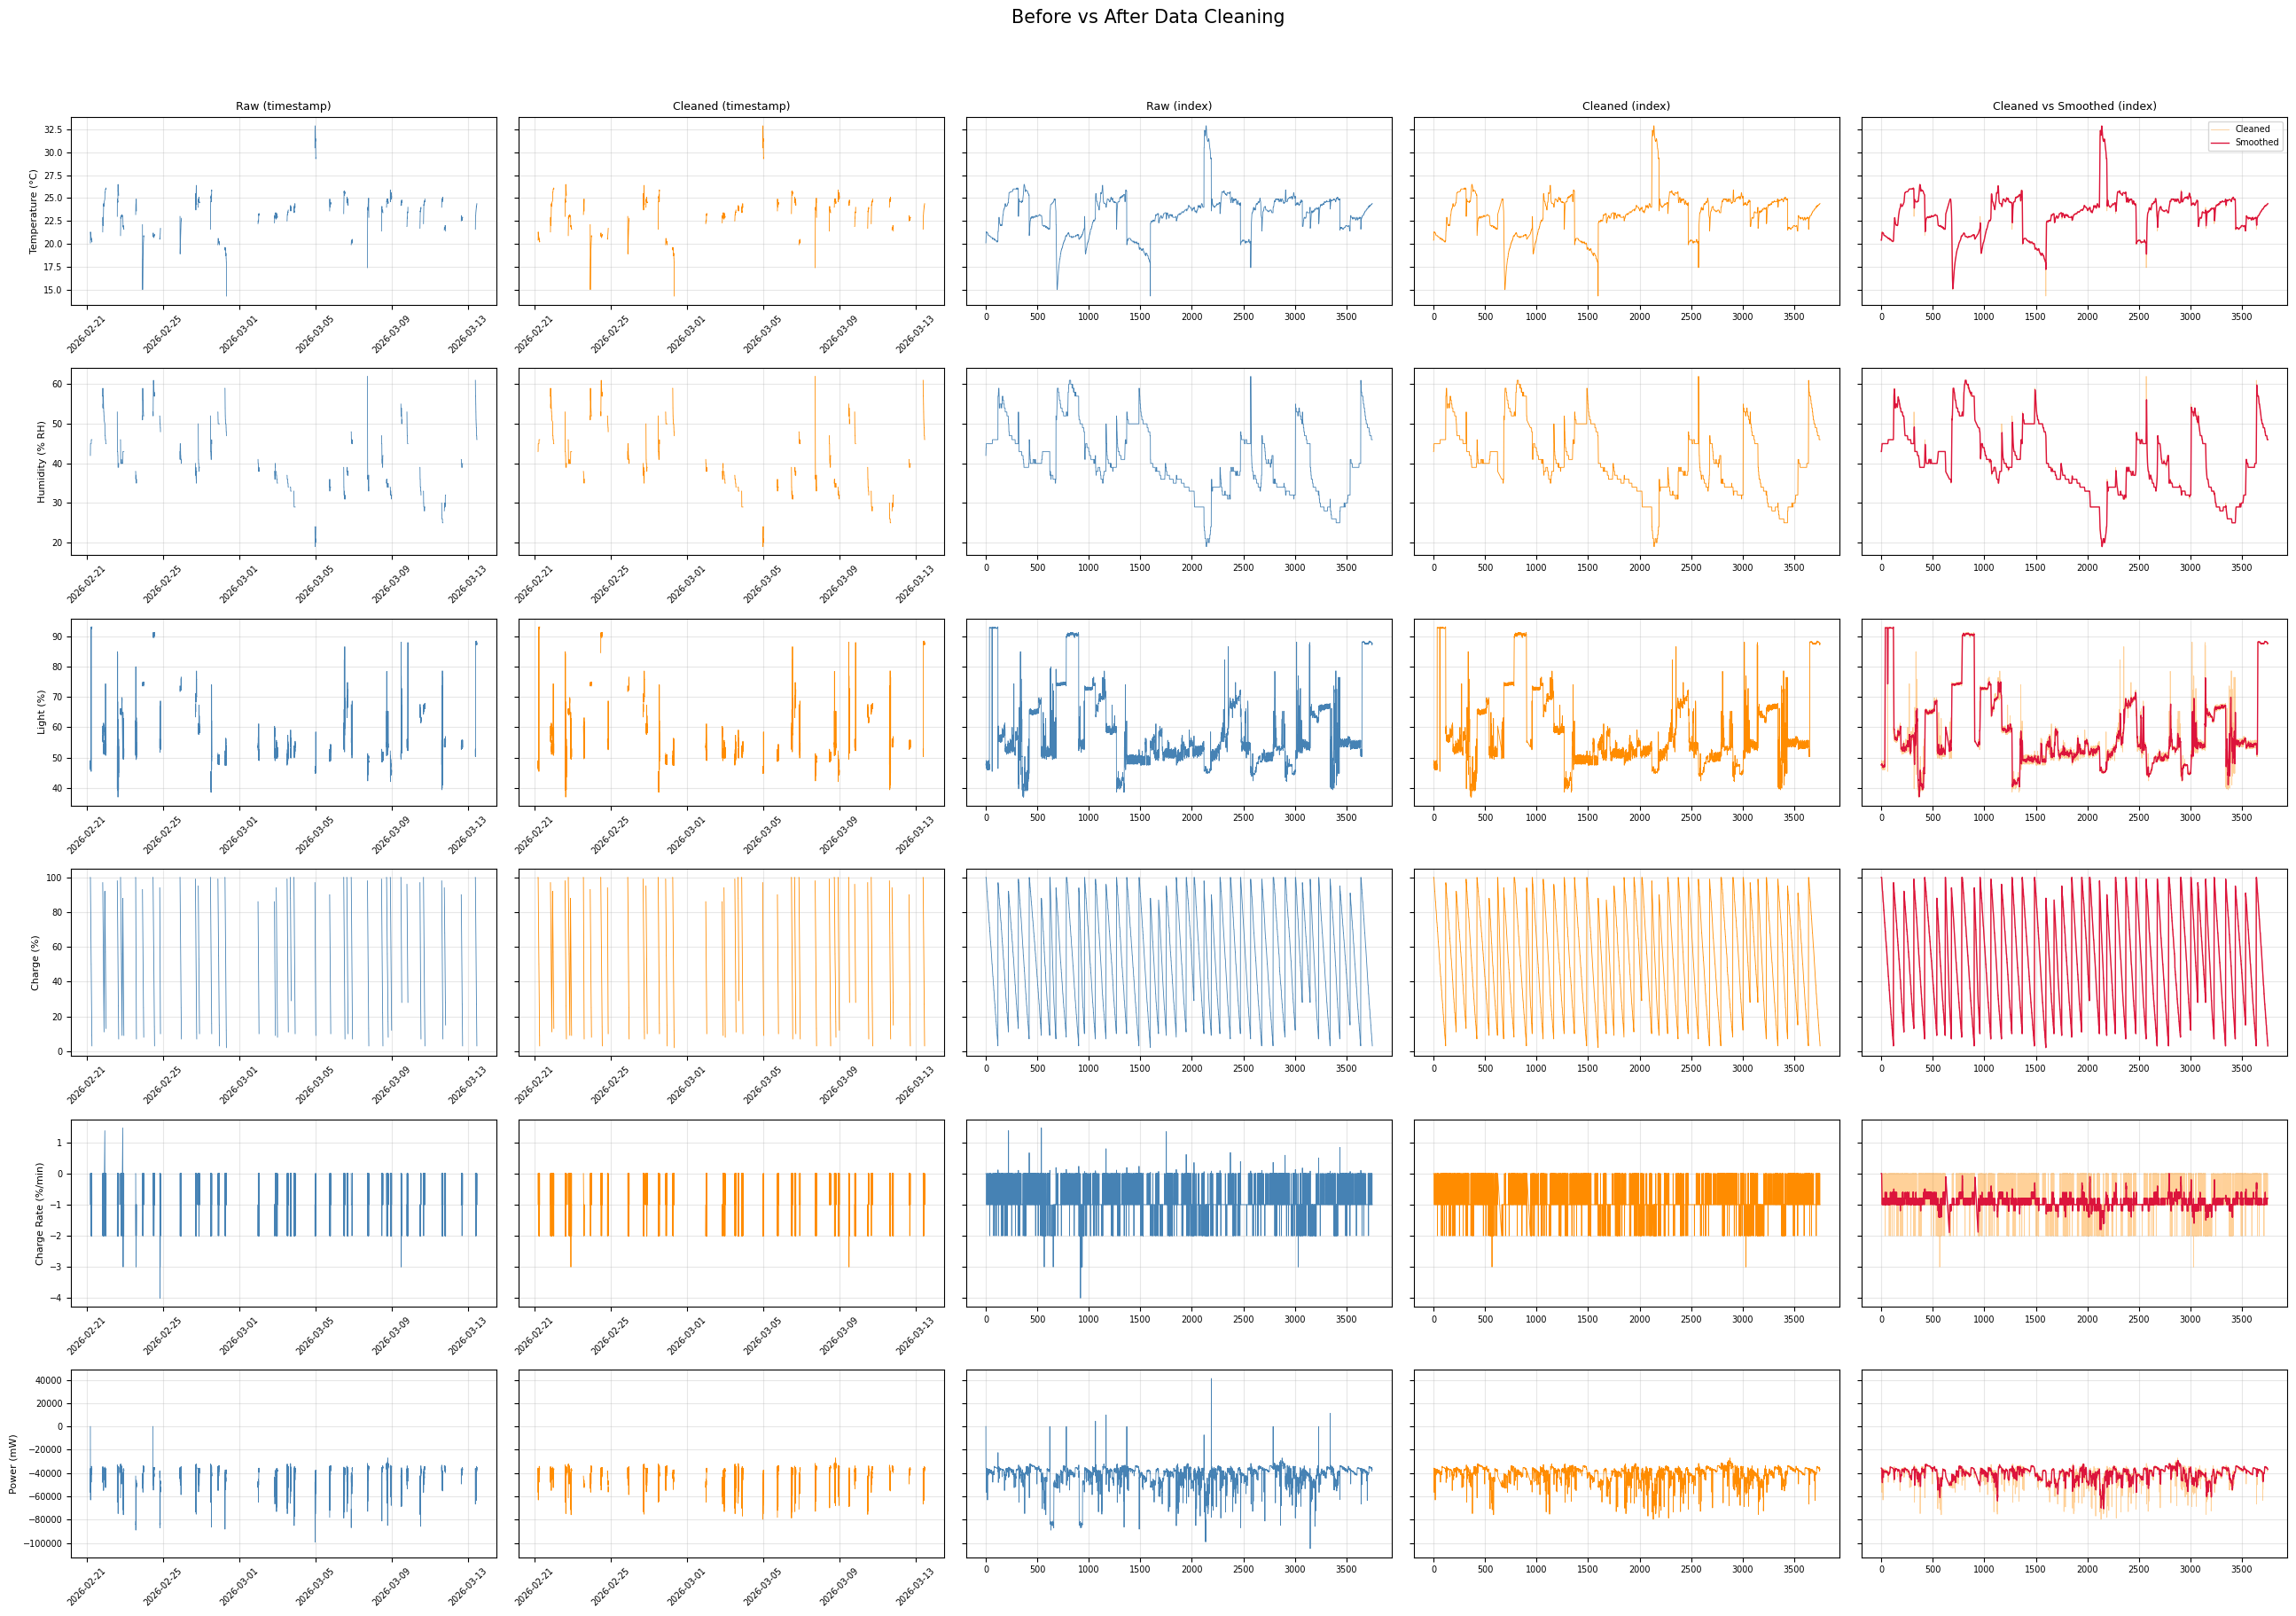


=== Before vs After Cleaning ===
Metric                                     Raw    Cleaned
---------------------------------------------------------
Total records                             3753       3753
Missing – temperature                        0          0
Missing – humidity                           0          0
Missing – lightPercent                       0          0
Missing – Charge_percent                     0          0
Missing – charge_rate                        0          0
Missing – power_consumption_mW               0          0

temperature:
  Raw     mean=23.25, std=2.20
  Cleaned mean=23.26, std=2.20
humidity:
  Raw     mean=40.53, std=8.56
  Cleaned mean=40.51, std=8.53
lightPercent:
  Raw     mean=58.59, std=12.52
  Cleaned mean=58.60, std=12.47
Charge_percent:
  Raw     mean=52.82, std=27.22
  Cleaned mean=52.82, std=27.22
charge_rate:
  Raw     mean=-0.91, std=0.51
  Cleaned mean=-0.90, std=0.48
power_consumption_mW:
  Raw     mean=-41498.49, std=9815.88
  C

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def visualize_before_after(df_raw, df_clean, df_smooth, gap_minutes=60):
    """
    5-column comparison per variable:
    Col 1: raw (timestamp)
    Col 2: cleaned (timestamp)
    Col 3: raw (index)
    Col 4: cleaned (index)
    Col 5: cleaned vs smoothed overlay (index)
    """

    # ===== Prepare raw data =====
    df_raw = df_raw.copy()
    df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
    df_raw = df_raw.sort_values('timestamp').reset_index(drop=True)
    time_diff_raw = df_raw['timestamp'].diff().dt.total_seconds() / 60
    df_raw_gap = df_raw.copy()

    # ===== Prepare cleaned data =====
    df_clean = df_clean.copy()
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
    df_clean = df_clean.sort_values('timestamp').reset_index(drop=True)
    time_diff_clean = df_clean['timestamp'].diff().dt.total_seconds() / 60
    df_clean_gap = df_clean.copy()

    # ===== Prepare smoothed data =====
    df_smooth = df_smooth.copy()
    df_smooth['timestamp'] = pd.to_datetime(df_smooth['timestamp'])
    df_smooth = df_smooth.sort_values('timestamp').reset_index(drop=True)
    df_smooth_gap = df_smooth.copy()

    variables = [
        ('temperature',          'Temperature (°C)'),
        ('humidity',             'Humidity (% RH)'),
        ('lightPercent',         'Light (%)'),
        ('Charge_percent',       'Charge (%)'),
        ('charge_rate',          'Charge Rate (%/min)'),
        ('power_consumption_mW', 'Power (mW)'),
    ]

    # Only keep variables present in both raw and cleaned
    variables = [(col, ylabel) for col, ylabel in variables
                 if col in df_raw.columns and col in df_clean.columns]

    shared_cols = [col for col, _ in variables]

    # Insert NaN at large time gaps to visually break the line
    for col in shared_cols:
        df_raw_gap.loc[time_diff_raw > gap_minutes, col]      = np.nan
        df_clean_gap.loc[time_diff_clean > gap_minutes, col]  = np.nan
        df_smooth_gap.loc[time_diff_clean > gap_minutes, col] = np.nan

    fig, axes = plt.subplots(len(variables), 5,
                             figsize=(26, 3 * len(variables)),
                             sharey='row')
    fig.suptitle('Before vs After Data Cleaning', fontsize=15, y=1.01)

    col_titles = [
        'Raw (timestamp)',
        'Cleaned (timestamp)',
        'Raw (index)',
        'Cleaned (index)',
        'Cleaned vs Smoothed (index)',
    ]
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=9)

    for i, (col, ylabel) in enumerate(variables):

        # ----- Col 0: raw timestamp -----
        if col in df_raw.columns:
            axes[i, 0].plot(df_raw_gap['timestamp'], df_raw_gap[col],
                            linewidth=0.6, color='steelblue')
        axes[i, 0].set_ylabel(ylabel, fontsize=8)
        axes[i, 0].tick_params(axis='x', rotation=45, labelsize=7)
        axes[i, 0].tick_params(axis='y', labelsize=7)
        axes[i, 0].grid(True, alpha=0.3)

        # ----- Col 1: cleaned timestamp -----
        if col in df_clean.columns:
            axes[i, 1].plot(df_clean_gap['timestamp'], df_clean_gap[col],
                            linewidth=0.6, color='darkorange')
        axes[i, 1].tick_params(axis='x', rotation=45, labelsize=7)
        axes[i, 1].tick_params(axis='y', labelsize=7)
        axes[i, 1].grid(True, alpha=0.3)

        # ----- Col 2: raw index -----
        if col in df_raw.columns:
            axes[i, 2].plot(df_raw.index, df_raw[col],
                            linewidth=0.6, color='steelblue')
        axes[i, 2].tick_params(axis='x', labelsize=7)
        axes[i, 2].tick_params(axis='y', labelsize=7)
        axes[i, 2].grid(True, alpha=0.3)

        # ----- Col 3: cleaned index -----
        if col in df_clean.columns:
            axes[i, 3].plot(df_clean.index, df_clean[col],
                            linewidth=0.6, color='darkorange')
        axes[i, 3].tick_params(axis='x', labelsize=7)
        axes[i, 3].tick_params(axis='y', labelsize=7)
        axes[i, 3].grid(True, alpha=0.3)

        # ----- Col 4: cleaned vs smoothed overlay -----
        if col in df_clean.columns:
            axes[i, 4].plot(df_clean.index, df_clean[col],
                            linewidth=0.6, color='darkorange', alpha=0.4,
                            label='Cleaned')
            axes[i, 4].plot(df_smooth.index, df_smooth[col],
                            linewidth=1.0, color='crimson',
                            label='Smoothed')
        axes[i, 4].tick_params(axis='x', labelsize=7)
        axes[i, 4].tick_params(axis='y', labelsize=7)
        axes[i, 4].grid(True, alpha=0.3)
        if i == 0:
            axes[i, 4].legend(fontsize=7, loc='upper right')

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

    # ===== Statistics comparison =====
    print("\n=== Before vs After Cleaning ===")
    print(f"{'Metric':<35} {'Raw':>10} {'Cleaned':>10}")
    print("-" * 57)
    print(f"{'Total records':<35} {len(df_raw):>10} {len(df_clean):>10}")

    for col in shared_cols:
        missing_raw   = df_raw[col].isnull().sum()
        missing_clean = df_clean[col].isnull().sum()
        print(f"{'Missing – ' + col:<35} {missing_raw:>10} {missing_clean:>10}")

    print()
    for col in shared_cols:
        mean_r, std_r = df_raw[col].mean(), df_raw[col].std()
        mean_c, std_c = df_clean[col].mean(), df_clean[col].std()
        print(f"{col}:")
        print(f"  Raw     mean={mean_r:.2f}, std={std_r:.2f}")
        print(f"  Cleaned mean={mean_c:.2f}, std={std_c:.2f}")

# ===== Execute =====
visualize_before_after(df_merged, df_cleaned, df_smoothed)

## Correlation

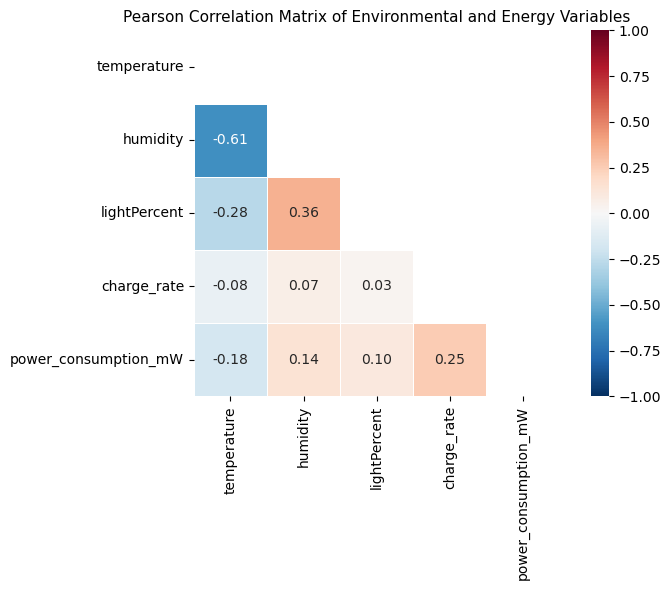


=== Correlations vs power_consumption_mW ===
  temperature                    r=-0.177  p=6.367e-28  ***
  humidity                       r=+0.142  p=2.759e-18  ***
  lightPercent                   r=+0.103  p=3.087e-10  ***
  charge_rate                    r=+0.251  p=4.939e-55  ***


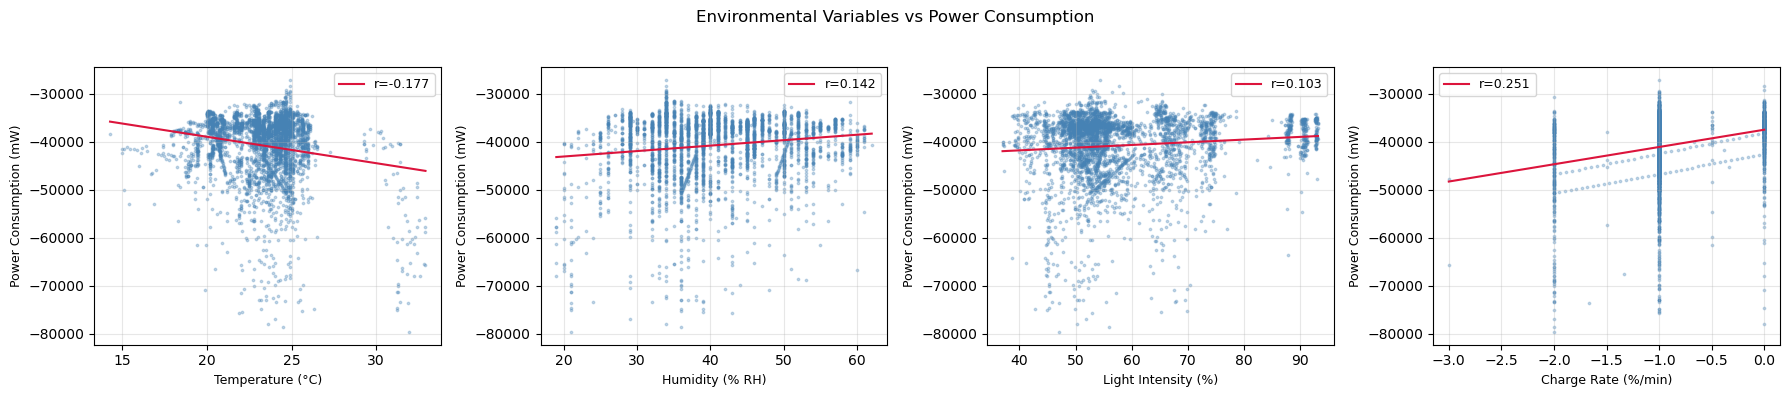

C:\Users\86068\AppData\Local\Temp\ipykernel_26068\1130673025.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([not_occupied, occupied],


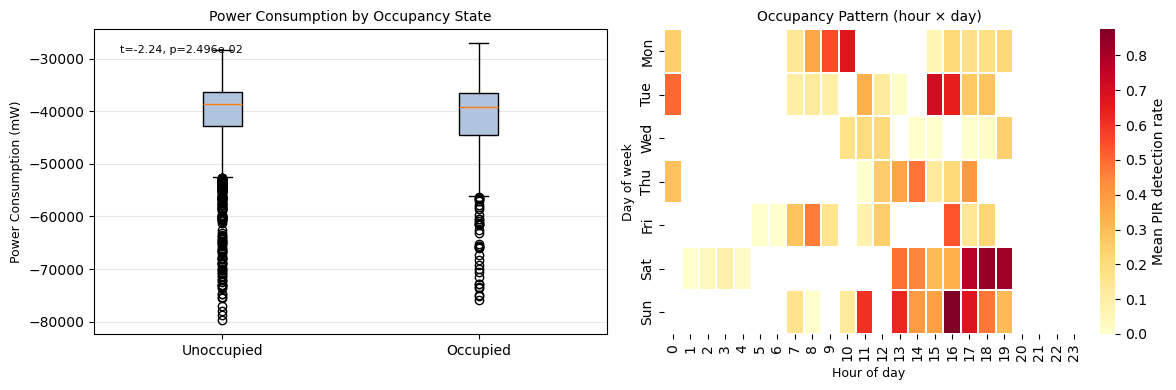


=== Occupancy vs Power (independent t-test) ===
  Occupied   mean: -41175.8 mW  (n=983)
  Unoccupied mean: -40606.2 mW  (n=2770)
  t=-2.243, p=2.496e-02


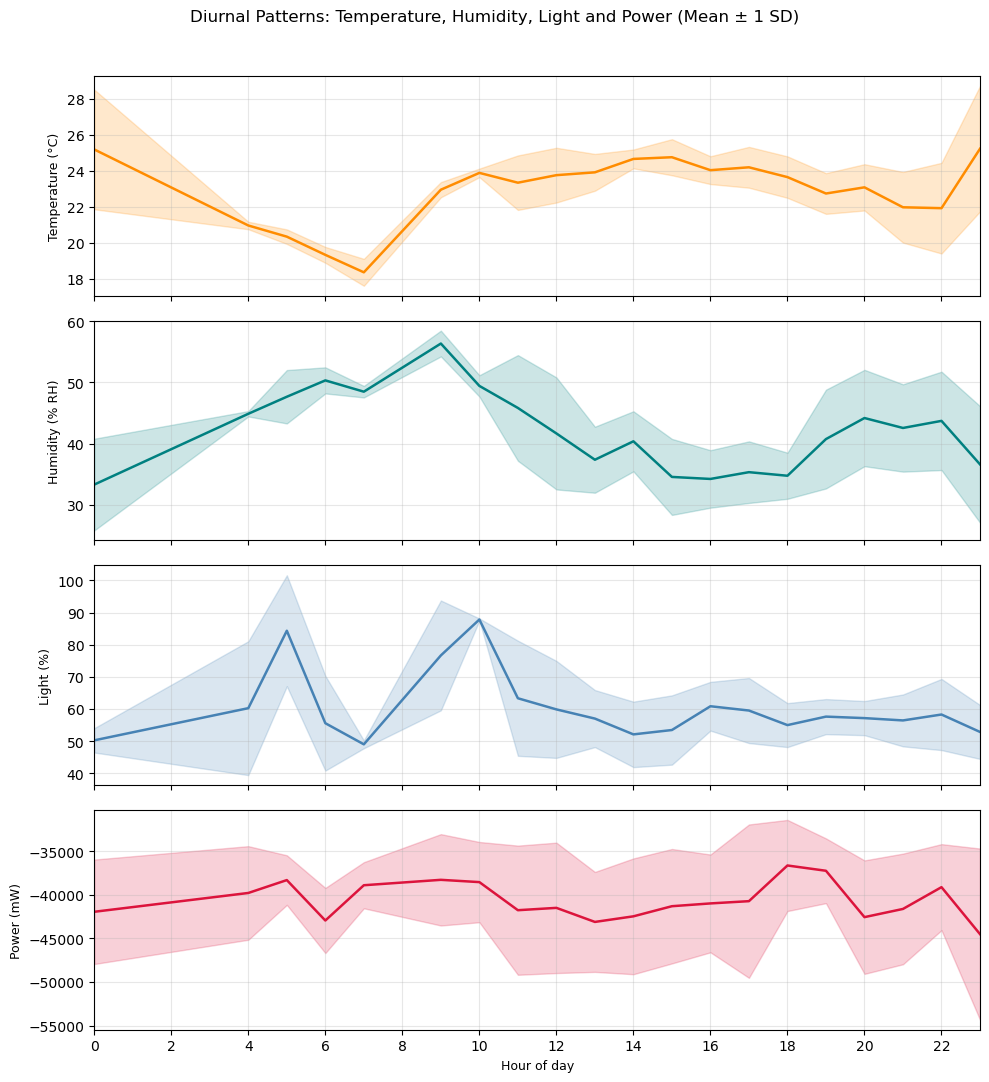

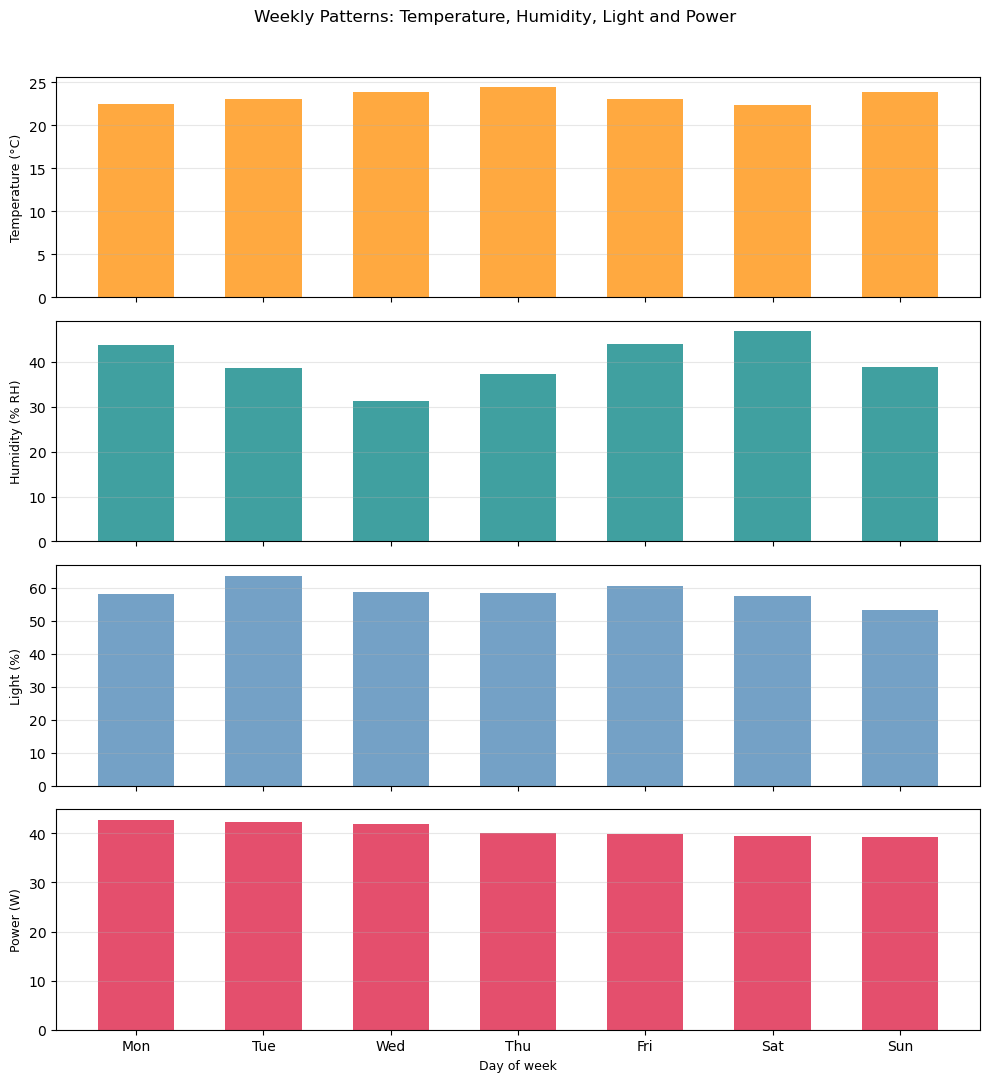


=== Cross-Correlation Peak Lags (vs power_consumption_mW) ===
  Light vs Power                     : peak lag= -2 min,  r=+0.110
  Temperature vs Power               : peak lag= +4 min,  r=-0.182
  Humidity vs Power                  : peak lag=+22 min,  r=+0.171
  PIR vs Power                       : peak lag= -7 min,  r=-0.091


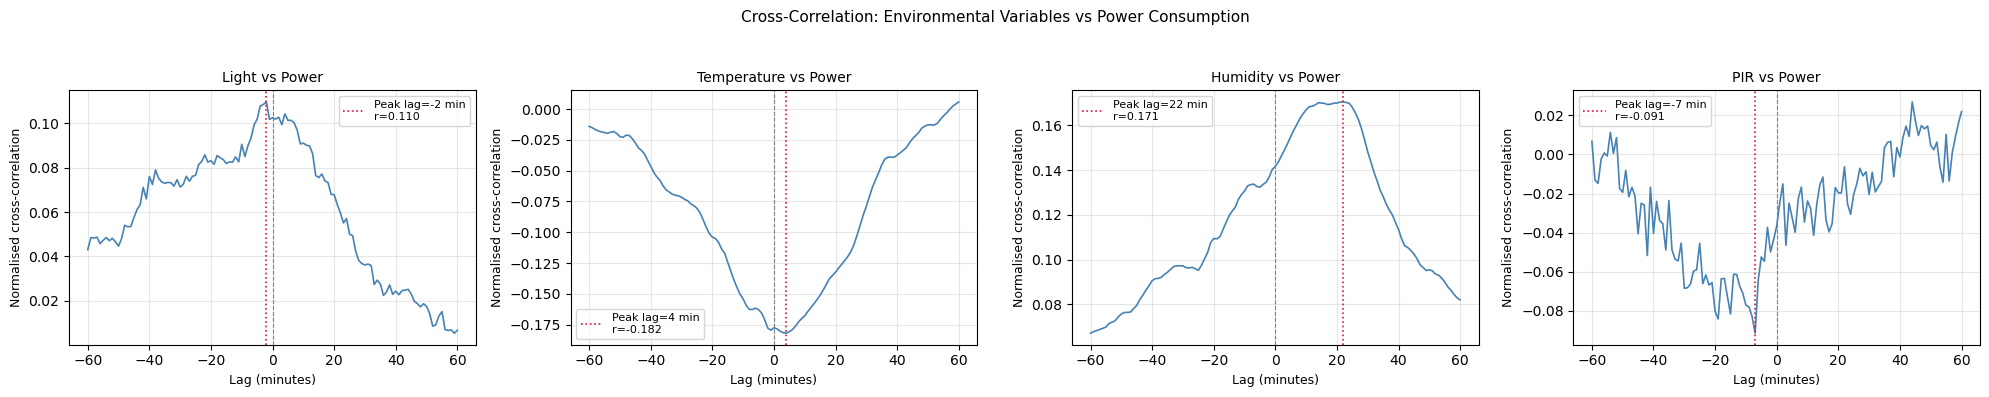

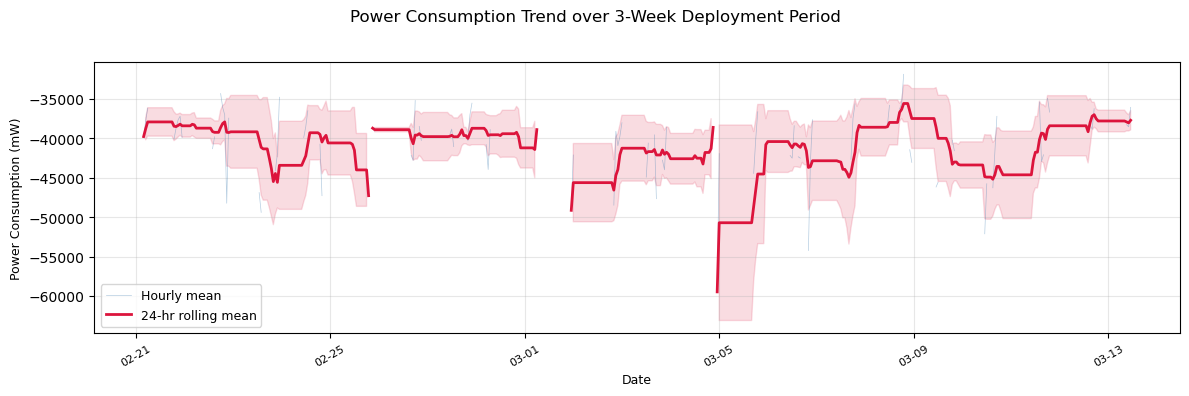


=== Descriptive Statistics ===
                           mean       std    median      min       max
temperature              23.256     2.198     23.60     14.3     32.90
humidity                 40.508     8.533     40.00     19.0     62.00
lightPercent             58.596    12.472     54.11     37.0     93.11
charge_rate              -0.904     0.477     -1.00     -3.0      0.00
power_consumption_mW -40755.411  6843.408 -38734.00 -79706.0 -27048.00


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.signal import correlate

def analyze_time_series(df_cleaned):
    df = df_cleaned.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

    df['hour']        = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek  # 0=Monday
    df['date']        = df['timestamp'].dt.date

    numeric_cols = ['temperature', 'humidity', 'lightPercent',
                    'charge_rate', 'power_consumption_mW']

    # ================================================================
    # 1. Pearson Correlation Matrix
    #    Goal: overview of all variable relationships,
    #          focus on the power_consumption_mW row
    # ================================================================
    fig, ax = plt.subplots(figsize=(8, 6))
    corr_matrix = df[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=ax, square=True, linewidths=0.5)
    ax.set_title('Pearson Correlation Matrix of Environmental and Energy Variables',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig('fig1_correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n=== Correlations vs power_consumption_mW ===")
    target = 'power_consumption_mW'
    for col in ['temperature', 'humidity', 'lightPercent', 'charge_rate']:
        if col not in df.columns:
            continue
        valid = df[[col, target]].dropna()
        r, p  = stats.pearsonr(valid[col], valid[target])
        sig   = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"  {col:<30s} r={r:+.3f}  p={p:.3e}  {sig}")

    # ================================================================
    # 2. Scatter plots: Environmental variables vs Power
    #    Goal: visualise linear/non-linear relationships
    # ================================================================
    env_vars = [
        ('temperature',  'Temperature (°C)'),
        ('humidity',     'Humidity (% RH)'),
        ('lightPercent', 'Light Intensity (%)'),
        ('charge_rate',  'Charge Rate (%/min)'),
    ]
    env_vars = [(c, l) for c, l in env_vars if c in df.columns]

    fig, axes = plt.subplots(1, len(env_vars),
                             figsize=(4.5 * len(env_vars), 4))
    for ax, (col, xlabel) in zip(axes, env_vars):
        valid = df[[col, target]].dropna()
        ax.scatter(valid[col], valid[target],
                   s=3, alpha=0.3, color='steelblue')
        m, b, r, p, _ = stats.linregress(valid[col], valid[target])
        x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
        ax.plot(x_line, m * x_line + b,
                color='crimson', linewidth=1.5, label=f'r={r:.3f}')
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('Power Consumption (mW)', fontsize=9)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    fig.suptitle('Environmental Variables vs Power Consumption', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('fig2_scatter_env_vs_power.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ================================================================
    # 3. PIR occupancy vs Power
    #    Goal: test whether human presence significantly affects power
    # ================================================================
    if 'pirDetected' in df.columns:
        occupied     = df.loc[df['pirDetected'] == 1, target].dropna()
        not_occupied = df.loc[df['pirDetected'] == 0, target].dropna()
        t, p_ttest   = stats.ttest_ind(occupied, not_occupied)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Box plot
        axes[0].boxplot([not_occupied, occupied],
                        labels=['Unoccupied', 'Occupied'],
                        patch_artist=True,
                        boxprops=dict(facecolor='lightsteelblue'))
        axes[0].set_ylabel('Power Consumption (mW)', fontsize=9)
        axes[0].set_title('Power Consumption by Occupancy State', fontsize=10)
        axes[0].text(0.05, 0.95, f't={t:.2f}, p={p_ttest:.3e}',
                     transform=axes[0].transAxes,
                     fontsize=8, verticalalignment='top')
        axes[0].grid(True, alpha=0.3, axis='y')

        # PIR activity heatmap (hour x day-of-week)
        day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
        pir_pivot  = (df.groupby(['day_of_week', 'hour'])['pirDetected']
                        .mean().unstack())
        sns.heatmap(pir_pivot, cmap='YlOrRd', ax=axes[1],
                    xticklabels=range(0, 24), yticklabels=day_labels,
                    linewidths=0.3,
                    cbar_kws={'label': 'Mean PIR detection rate'})
        axes[1].set_xlabel('Hour of day', fontsize=9)
        axes[1].set_ylabel('Day of week', fontsize=9)
        axes[1].set_title('Occupancy Pattern (hour × day)', fontsize=10)

        plt.tight_layout()
        plt.savefig('fig3_pir_vs_power.png', dpi=150, bbox_inches='tight')
        plt.show()

        print(f"\n=== Occupancy vs Power (independent t-test) ===")
        print(f"  Occupied   mean: {occupied.mean():.1f} mW  (n={len(occupied)})")
        print(f"  Unoccupied mean: {not_occupied.mean():.1f} mW  (n={len(not_occupied)})")
        print(f"  t={t:.3f}, p={p_ttest:.3e}")

    # # ================================================================
    # # 4. Diurnal Pattern (hourly average)
    # #    Goal: show 24-hour periodicity of light, temperature, power
    # # ================================================================
    # hourly    = df.groupby('hour')[
    #     ['lightPercent', 'temperature', 'power_consumption_mW']
    # ].agg(['mean', 'std'])

    # fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    # plot_vars = [
    #     ('lightPercent',         'Light (%)',        'steelblue'),
    #     ('temperature',          'Temperature (°C)', 'darkorange'),
    #     ('power_consumption_mW', 'Power (mW)',       'crimson'),
    # ]
    # for ax, (col, ylabel, color) in zip(axes, plot_vars):
    #     mean = hourly[col]['mean']
    #     std  = hourly[col]['std']
    #     ax.plot(mean.index, mean.values, color=color, linewidth=1.8)
    #     ax.fill_between(mean.index, mean - std, mean + std,
    #                     alpha=0.2, color=color)
    #     ax.set_ylabel(ylabel, fontsize=9)
    #     ax.grid(True, alpha=0.3)
    #     ax.set_xlim(0, 23)
    # axes[-1].set_xlabel('Hour of day', fontsize=9)
    # axes[-1].set_xticks(range(0, 24, 2))
    # fig.suptitle('Diurnal Patterns: Light, Temperature and Power (Mean ± 1 SD)',
    #              fontsize=12)
    # plt.tight_layout(rect=[0, 0, 1, 0.96])
    # plt.savefig('fig4_diurnal_pattern.png', dpi=150, bbox_inches='tight')
    # plt.show()

    # # ================================================================
    # # 5. Weekly Pattern
    # #    Goal: identify weekday vs weekend differences in power usage
    # # ================================================================
    # day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    # weekly     = df.groupby('day_of_week')[
    #     ['lightPercent', 'power_consumption_mW']
    # ].mean()

    # fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    # for ax, (col, ylabel, color) in zip(axes, [
    #     ('lightPercent',         'Light (%)',  'steelblue'),
    #     ('power_consumption_mW', 'Power (mW)', 'crimson'),
    # ]):
    #     ax.bar(weekly.index, weekly[col],
    #            color=color, alpha=0.75, width=0.6)
    #     ax.set_ylabel(ylabel, fontsize=9)
    #     ax.grid(True, alpha=0.3, axis='y')
    # axes[-1].set_xticks(range(7))
    # axes[-1].set_xticklabels(day_labels)
    # axes[-1].set_xlabel('Day of week', fontsize=9)
    # fig.suptitle('Weekly Patterns: Light and Power Consumption', fontsize=12)
    # plt.tight_layout(rect=[0, 0, 1, 0.96])
    # plt.savefig('fig5_weekly_pattern.png', dpi=150, bbox_inches='tight')
    # plt.show()
 
    # ================================================================
    # 4. Diurnal Pattern — Temperature, Humidity, Light, Power
    # ================================================================
    hourly = df.groupby('hour')[
        ['temperature', 'humidity', 'lightPercent', 'power_consumption_mW']
    ].agg(['mean', 'std'])

    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    plot_vars = [
        ('temperature',          'Temperature (°C)', 'darkorange'),
        ('humidity',             'Humidity (% RH)',  'teal'),
        ('lightPercent',         'Light (%)',        'steelblue'),
        ('power_consumption_mW', 'Power (mW)',       'crimson'),
    ]
    for ax, (col, ylabel, color) in zip(axes, plot_vars):
        mean = hourly[col]['mean']
        std  = hourly[col]['std']
        ax.plot(mean.index, mean.values, color=color, linewidth=1.8)
        ax.fill_between(mean.index, mean - std, mean + std,
                        alpha=0.2, color=color)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 23)
    axes[-1].set_xlabel('Hour of day', fontsize=9)
    axes[-1].set_xticks(range(0, 24, 2))
    fig.suptitle('Diurnal Patterns: Temperature, Humidity, Light and Power (Mean ± 1 SD)',
                 fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('fig4_diurnal_pattern.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ================================================================
    # 5. Weekly Pattern — Temperature, Humidity, Light, Power
    # ================================================================
    day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

    weekly_power = df.groupby('day_of_week')['power_consumption_mW'].mean().abs() / 1000
    weekly_temp  = df.groupby('day_of_week')['temperature'].mean()
    weekly_hum   = df.groupby('day_of_week')['humidity'].mean()
    weekly_light = df.groupby('day_of_week')['lightPercent'].mean()

    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    bar_vars = [
        (weekly_temp,  'Temperature (°C)', 'darkorange'),
        (weekly_hum,   'Humidity (% RH)',  'teal'),
        (weekly_light, 'Light (%)',        'steelblue'),
        (weekly_power, 'Power (W)',        'crimson'),
    ]
    for ax, (data, ylabel, color) in zip(axes, bar_vars):
        ax.bar(data.index, data.values, color=color, alpha=0.75, width=0.6)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
    axes[-1].set_xticks(range(7))
    axes[-1].set_xticklabels(day_labels)
    axes[-1].set_xlabel('Day of week', fontsize=9)
    fig.suptitle('Weekly Patterns: Temperature, Humidity, Light and Power', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('fig5_weekly_pattern.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ================================================================
    # 6. Cross-Correlation Analysis
    #    Goal: quantify time-lag relationships between environmental
    #          variables and power consumption (10% weight requirement)
    # ================================================================
    max_lag     = 60
    cross_pairs = [
        ('lightPercent', 'power_consumption_mW', 'Light vs Power'),
        ('temperature',  'power_consumption_mW', 'Temperature vs Power'),
        ('humidity',     'power_consumption_mW', 'Humidity vs Power'),
    ]
    if 'pirDetected' in df.columns:
        cross_pairs.append(
            ('pirDetected', 'power_consumption_mW', 'PIR vs Power')
        )
    cross_pairs = [(a, b, t) for a, b, t in cross_pairs if a in df.columns]

    n_pairs = len(cross_pairs)
    fig, axes = plt.subplots(1, n_pairs, figsize=(5 * n_pairs, 4))
    if n_pairs == 1:
        axes = [axes]

    print("\n=== Cross-Correlation Peak Lags (vs power_consumption_mW) ===")
    for ax, (col_a, col_b, title) in zip(axes, cross_pairs):
        a = df[col_a].fillna(df[col_a].mean()).values
        b = df[col_b].fillna(df[col_b].mean()).values
        a = (a - a.mean()) / (a.std() + 1e-9)
        b = (b - b.mean()) / (b.std() + 1e-9)

        xcorr      = correlate(a, b, mode='full') / len(a)
        lags       = np.arange(-len(a) + 1, len(a))
        mid        = len(lags) // 2
        lags_trim  = lags[mid - max_lag : mid + max_lag + 1]
        xcorr_trim = xcorr[mid - max_lag : mid + max_lag + 1]
        peak_idx   = np.argmax(np.abs(xcorr_trim))
        peak_lag   = lags_trim[peak_idx]
        peak_val   = xcorr_trim[peak_idx]

        ax.plot(lags_trim, xcorr_trim, linewidth=1.2, color='steelblue')
        ax.axvline(0,        color='gray',   linestyle='--', linewidth=0.8)
        ax.axvline(peak_lag, color='crimson', linestyle=':',  linewidth=1.2,
                   label=f'Peak lag={peak_lag} min\nr={peak_val:.3f}')
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Lag (minutes)', fontsize=9)
        ax.set_ylabel('Normalised cross-correlation', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        print(f"  {title:<35s}: peak lag={peak_lag:+3d} min,  r={peak_val:+.3f}")

    fig.suptitle('Cross-Correlation: Environmental Variables vs Power Consumption',
                 fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig('fig6_cross_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ================================================================
    # 7. Power Consumption Trend over 3 weeks (24-hr rolling mean)
    #    Goal: show overall power trend across the deployment period
    # ================================================================
    df_hourly = (df.set_index('timestamp')
                   .resample('1h')
                   .mean(numeric_only=True))
    roll = df_hourly['power_consumption_mW'].rolling(window=24, min_periods=1)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df_hourly.index, df_hourly['power_consumption_mW'],
            linewidth=0.5, color='steelblue', alpha=0.4, label='Hourly mean')
    ax.plot(df_hourly.index, roll.mean(),
            linewidth=2, color='crimson', label='24-hr rolling mean')
    ax.fill_between(df_hourly.index,
                    roll.mean() - roll.std(),
                    roll.mean() + roll.std(),
                    alpha=0.15, color='crimson')
    ax.set_ylabel('Power Consumption (mW)', fontsize=9)
    ax.set_xlabel('Date', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.suptitle('Power Consumption Trend over 3-Week Deployment Period',
                 fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('fig7_power_trend.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ================================================================
    # 8. Descriptive Statistics
    # ================================================================
    print("\n=== Descriptive Statistics ===")
    desc = df[numeric_cols].describe().T[['mean', 'std', '50%', 'min', 'max']]
    desc.columns = ['mean', 'std', 'median', 'min', 'max']
    print(desc.round(3).to_string())

    return df

# ===== Execute =====
df_analyzed = analyze_time_series(df_cleaned)

In [12]:
# ===== Export cleaned data for analysis =====
df_cleaned.to_csv('df_cleaned.csv', index=False)
print("Exported df_cleaned.csv")
print(f"Shape: {df_cleaned.shape}")
print(df_cleaned.head())

Exported df_cleaned.csv
Shape: (3753, 8)
            timestamp  temperature  humidity  lightPercent  pirDetected  Charge_percent  charge_rate  power_consumption_mW
0 2026-02-21 04:11:00         20.4      43.0         47.57            0           100.0          0.0              -35744.0
1 2026-02-21 04:12:00         20.4      43.0         47.57            0           100.0          0.0              -35744.0
2 2026-02-21 04:13:00         20.7      44.0         48.16            0           100.0          0.0              -35792.0
3 2026-02-21 04:14:00         20.9      44.0         46.86            0           100.0          0.0              -35952.0
4 2026-02-21 04:15:00         21.2      45.0         49.08            0            99.0         -1.0              -37343.0
